image shape: (1572, 1147, 3)
mask shape: (1572, 1147)


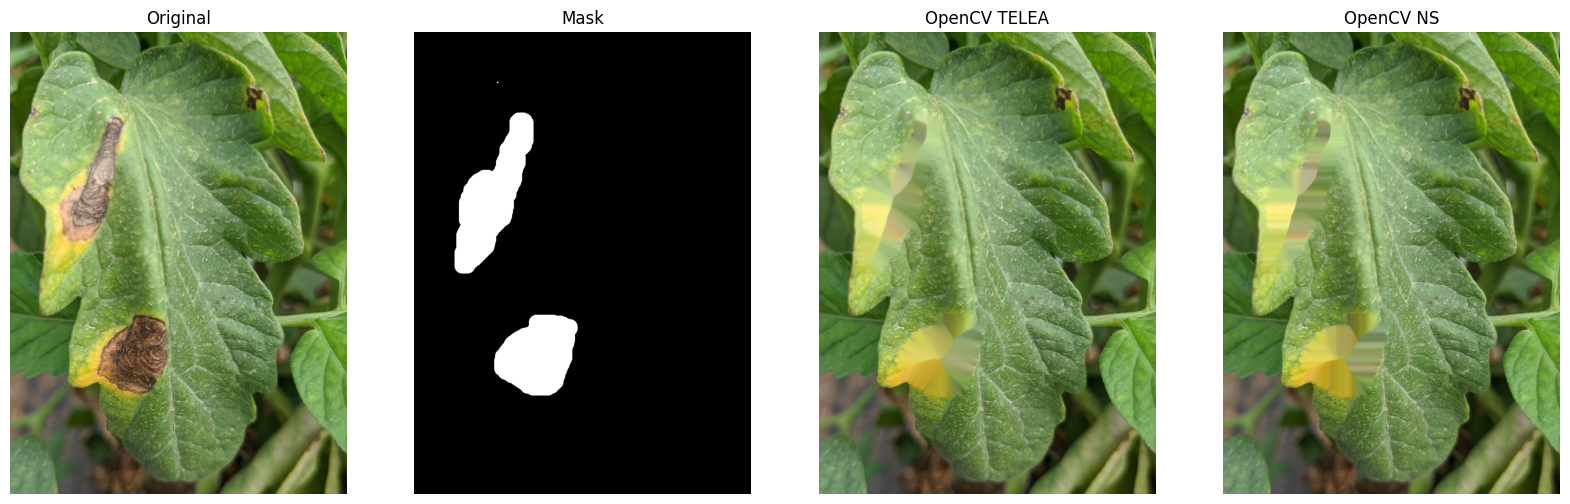

저장 완료: /home/harry/Re_leaf_Project/Inpainting/output/early_blight1_cv_inpaint.png


In [2]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# =========================
# 1. 경로 설정
# =========================

BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting"

ORIGINAL_PATH = os.path.join(
    BASE_DIR,
    "original",
    "Tomato Early Blight1.jpg"
)

MASK_PATH = os.path.join(
    BASE_DIR,
    "mask",
    "Tomato Early Blight1.png"
)

OUTPUT_DIR = os.path.join(BASE_DIR, "output")

CV_RESULT_PATH = os.path.join(OUTPUT_DIR, "early_blight1_cv_inpaint.png")

# =========================
# 2. 이미지 로드
# =========================

image = cv2.imread(ORIGINAL_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)

print("image shape:", image.shape)
print("mask shape:", mask.shape)

# =========================
# 3. mask 이진화
# 흰색 = 복원할 영역
# 검정 = 유지할 영역
# =========================

_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# =========================
# 4. mask 살짝 확장
# 병반 가장자리까지 같이 제거하기 위함
# =========================

kernel = np.ones((5, 5), np.uint8)
mask_dilated = cv2.dilate(mask_bin, kernel, iterations=1)

# =========================
# 5. 1차 복원
# radius 값이 클수록 넓게 주변을 참고함
# =========================

result_telea = cv2.inpaint(
    image,
    mask_dilated,
    inpaintRadius=7,
    flags=cv2.INPAINT_TELEA
)

result_ns = cv2.inpaint(
    image,
    mask_dilated,
    inpaintRadius=7,
    flags=cv2.INPAINT_NS
)

# =========================
# 6. 비교 시각화
# =========================

plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(mask_dilated, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(result_telea)
plt.title("OpenCV TELEA")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(result_ns)
plt.title("OpenCV NS")
plt.axis("off")

plt.show()

# =========================
# 7. 저장
# 일단 TELEA 결과 저장
# =========================

Image.fromarray(result_telea).save(CV_RESULT_PATH)

print("저장 완료:", CV_RESULT_PATH)